# E-Commerce Customer Behavior Analysis (EDA)  
## CodeAlpha Data Analytics Internship – Task 2 : Exploratory Data Analysis (EDA)

### 1. Project Overview

This notebook performs an in-depth Exploratory Data Analysis (EDA) on an e-commerce customer behavior dataset.  
The main goal is to understand how customers interact with the online store, how they purchase, and which segments create the most value for the business.

The dataset contains customer demographics, browsing information, and purchase behavior.  
Analyzing these patterns helps data-driven decision making in marketing, personalization, and product strategy.

---

### 2. Business Importance of the Dataset

Understanding customer behavior is critical for any e-commerce business because it directly affects:

- **Revenue optimization**: Identifying high-value customers and drivers of higher purchase amounts.  
- **Customer segmentation**: Grouping customers by behavior to target them with relevant campaigns.  
- **Conversion improvement**: Detecting factors that increase or decrease the probability of purchase.  
- **Retention strategies**: Recognizing patterns linked to loyal or at-risk customers.

This analysis links statistical findings with visual insights to build a clear and actionable view of how customers behave across the platform.

---

### 3. Key Questions Addressed in This EDA

This notebook is designed to answer questions such as:

1. Which customer segments (age, device type, location, etc.) generate the highest purchase amounts?  
2. How do demographic features relate to shopping behavior and spending patterns?  
3. Are there strong relationships (correlations) between features such as time on site, number of visits, and purchase value?  
4. What data quality issues (missing values, outliers, duplicates) exist in the dataset, and how might they affect analysis?  
5. Are there statistically significant differences between different customer groups?

These questions guide the entire EDA process and ensure that each step has a clear purpose.

---

### 4. EDA Workflow and Structure of This Notebook

The analysis is organized into a sequence of structured steps:

1. **Loading and Inspecting Data**  
   - Import required libraries (pandas, numpy, seaborn, matplotlib, scipy).  
   - Load the e-commerce customer behavior dataset.  
   - Display basic information (shape, dtypes, preview of records).  
   *Purpose*: Build a first understanding of the dataset structure and content.

2. **Descriptive Statistics – Univariate Analysis**  
   - Generate summary statistics for numerical features (mean, median, std, min, max, quartiles).  
   - Inspect distributions of categorical variables via value counts.  
   *Purpose*: Understand central tendencies, variability, and basic frequency distributions.

3. **Detailed Statistical Profiling of Numerical Features**  
   - Compute additional metrics such as range, skewness, kurtosis, and IQR.  
   *Purpose*: Detect non-normal distributions, asymmetry, and potential heavy tails that may indicate outliers or specific patterns in behavior.

4. **Univariate Visualization (Histograms and Box Plots)**  
   - Plot histograms with mean and median lines for numerical columns.  
   - Create box plots to visually identify outliers.  
   *Purpose*: Visually confirm statistical findings and make distribution shapes and extreme values more intuitive.

5. **Outlier Detection and Interpretation**  
   - Use the IQR method to flag and count outliers for key numerical variables.  
   *Purpose*: Highlight extreme customer behaviors that may represent errors, anomalies, or special high-impact segments.

6. **Correlation Analysis (Statistics)**  
   - Compute the correlation matrix for numerical features.  
   - Identify strong positive or negative correlations.  
   *Purpose*: Quantify relationships between variables such as time spent, visits, and purchase amount to support hypothesis building.

7. **Correlation Visualization (Heatmap)**  
   - Visualize the correlation matrix using a color-coded heatmap.  
   *Purpose*: Provide an intuitive, high-level view of how all numerical variables interact with each other.

8. **Categorical Feature Analysis**  
   - Analyze distributions of categorical variables (e.g., device type, gender, region, or customer segments).  
   - Compute counts and percentage shares for each category.  
   *Purpose*: Understand the composition of the customer base and the relative weight of each group.

9. **Categorical Visualization (Bar Charts)**  
   - Plot bar charts for key categorical columns.  
   *Purpose*: Make the distribution of categories easy to compare and communicate.

10. **Bivariate Analysis: Numerical vs Categorical**  
    - Group numerical metrics (e.g., purchase amount) by categorical variables (e.g., device type, gender).  
    - Compute aggregated statistics (count, mean, median, std) for each group.  
    *Purpose*: Identify which segments are more valuable or behave differently from others.

11. **Cross-tabulation Between Categorical Variables**  
    - Build cross-tab tables and percentage distributions between pairs of categorical features.  
    *Purpose*: Reveal relationships between segment attributes, such as combinations of device type and customer group.

12. **Bivariate Visualization: Scatter Plots and Trend Lines**  
    - Plot scatter relationships between important numerical variables.  
    - Add trend lines to show direction and strength of relationships visually.  
    *Purpose*: Visually detect linear or non-linear patterns between key behavioral metrics.

13. **Segment-Level Analysis (Grouped Statistics and Plots)**  
    - Compute descriptive statistics by customer segment.  
    - Use grouped bar charts to compare average behavior across segments.  
    *Purpose*: Support customer segmentation and identify high-impact groups for targeted actions.

14. **Hypothesis Testing (Statistical Validation)**  
    - Perform normality tests (Shapiro–Wilk) on numerical features.  
    - Perform Pearson correlation tests to validate correlation significance.  
    - Run independent t-tests (where applicable) to compare means between two groups.  
    *Purpose*: Move from visual intuition to statistically validated conclusions.

15. **Data Quality Assessment**  
    - Measure missing values, duplicates, and outlier percentages.  
    - Report value ranges for main numerical variables.  
    *Purpose*: Document data reliability and highlight potential limitations of the analysis.

16. **Key Insights Summary**  
    - Summarize the main findings across demographics, behavior, correlations, and segment performance.  
    *Purpose*: Provide a concise, business-oriented conclusion that can be used directly in reports or presentations.

---

### 5. Tools and Technologies Used

- **Programming Language**: Python  
- **Environment**: Jupyter / Google Colab  
- **Libraries**:  
  - `pandas`, `numpy` for data manipulation and numerical computations  
  - `matplotlib`, `seaborn` for data visualization  
  - `scipy.stats` for hypothesis testing and advanced statistics  

The combination of statistics and visualization ensures that the analysis is both rigorous and easy to interpret for technical and non-technical stakeholders.


#Loading and Prepare Data

In [1]:
# Import essential libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import kagglehub
warnings.filterwarnings('ignore')

# Configure visualization settings for professional appearance
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the E-commerce Customer Behavior Dataset from Kaggle
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("uom190346a/e-commerce-customer-behavior-dataset")
print("Path to dataset files:", path)

import os

# List files inside the downloaded dataset directory
print(os.listdir(path))

# Load the main CSV file
df = pd.read_csv(os.path.join(path, "E-commerce Customer Behavior - Sheet1.csv"))

# Display dataset overview
print("Dataset Overview:")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)


100%|██████████| 2.84k/2.84k [00:00<00:00, 1.82MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uom190346a/e-commerce-customer-behavior-dataset/versions/1
['E-commerce Customer Behavior - Sheet1.csv']
Dataset Overview:
   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since 

#Primery Discover

In [2]:
# Perform initial data exploration and quality checks
print("=" * 80)
print("DESCRIPTIVE STATISTICS - UNIVARIATE ANALYSIS")
print("=" * 80)

# Generate statistical summary for all numerical columns
print("\nNumerical Summary:")
print(df.describe())

# Identify missing values
print("\n\nMissing Values Count:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Get detailed dataset information
print("\n\nData Info:")
print(df.info())

# Display categorical variables distribution
print("\n\nCategorical Variables Distribution:")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


DESCRIPTIVE STATISTICS - UNIVARIATE ANALYSIS

Numerical Summary:
       Customer ID         Age  Total Spend  Items Purchased  Average Rating  \
count   350.000000  350.000000   350.000000       350.000000      350.000000   
mean    275.500000   33.597143   845.381714        12.600000        4.019143   
std     101.180532    4.870882   362.058695         4.155984        0.580539   
min     101.000000   26.000000   410.800000         7.000000        3.000000   
25%     188.250000   30.000000   502.000000         9.000000        3.500000   
50%     275.500000   32.500000   775.200000        12.000000        4.100000   
75%     362.750000   37.000000  1160.600000        15.000000        4.500000   
max     450.000000   43.000000  1520.100000        21.000000        4.900000   

       Days Since Last Purchase  
count                350.000000  
mean                  26.588571  
std                   13.440813  
min                    9.000000  
25%                   15.000000  
50%       

#comprehensive statistical

In [3]:
# Calculate comprehensive statistical measures for numerical variables
print("=" * 80)
print("DETAILED STATISTICAL ANALYSIS")
print("=" * 80)

numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    print(f"\n{col.upper()} Statistics:")
    print(f"  Mean:              {df[col].mean():.2f}")
    print(f"  Median:            {df[col].median():.2f}")
    print(f"  Mode:              {df[col].mode().values[0]:.2f}" if not df[col].mode().empty else "  Mode:              N/A")
    print(f"  Std Deviation:     {df[col].std():.2f}")
    print(f"  Variance:          {df[col].var():.2f}")
    print(f"  Min:               {df[col].min():.2f}")
    print(f"  Max:               {df[col].max():.2f}")
    print(f"  Range:             {df[col].max() - df[col].min():.2f}")
    print(f"  Skewness:          {df[col].skew():.3f}")
    print(f"  Kurtosis:          {df[col].kurtosis():.3f}")
    print(f"  Q1 (25%):          {df[col].quantile(0.25):.2f}")
    print(f"  Q3 (75%):          {df[col].quantile(0.75):.2f}")
    print(f"  IQR:               {df[col].quantile(0.75) - df[col].quantile(0.25):.2f}")


DETAILED STATISTICAL ANALYSIS

CUSTOMER ID Statistics:
  Mean:              275.50
  Median:            275.50
  Mode:              101.00
  Std Deviation:     101.18
  Variance:          10237.50
  Min:               101.00
  Max:               450.00
  Range:             349.00
  Skewness:          0.000
  Kurtosis:          -1.200
  Q1 (25%):          188.25
  Q3 (75%):          362.75
  IQR:               174.50

AGE Statistics:
  Mean:              33.60
  Median:            32.50
  Mode:              30.00
  Std Deviation:     4.87
  Variance:          23.73
  Min:               26.00
  Max:               43.00
  Range:             17.00
  Skewness:          0.468
  Kurtosis:          -0.773
  Q1 (25%):          30.00
  Q3 (75%):          37.00
  IQR:               7.00

TOTAL SPEND Statistics:
  Mean:              845.38
  Median:            775.20
  Mode:              710.40
  Std Deviation:     362.06
  Variance:          131086.50
  Min:               410.80
  Max:           

#Histograms


Generating Univariate Visualizations...


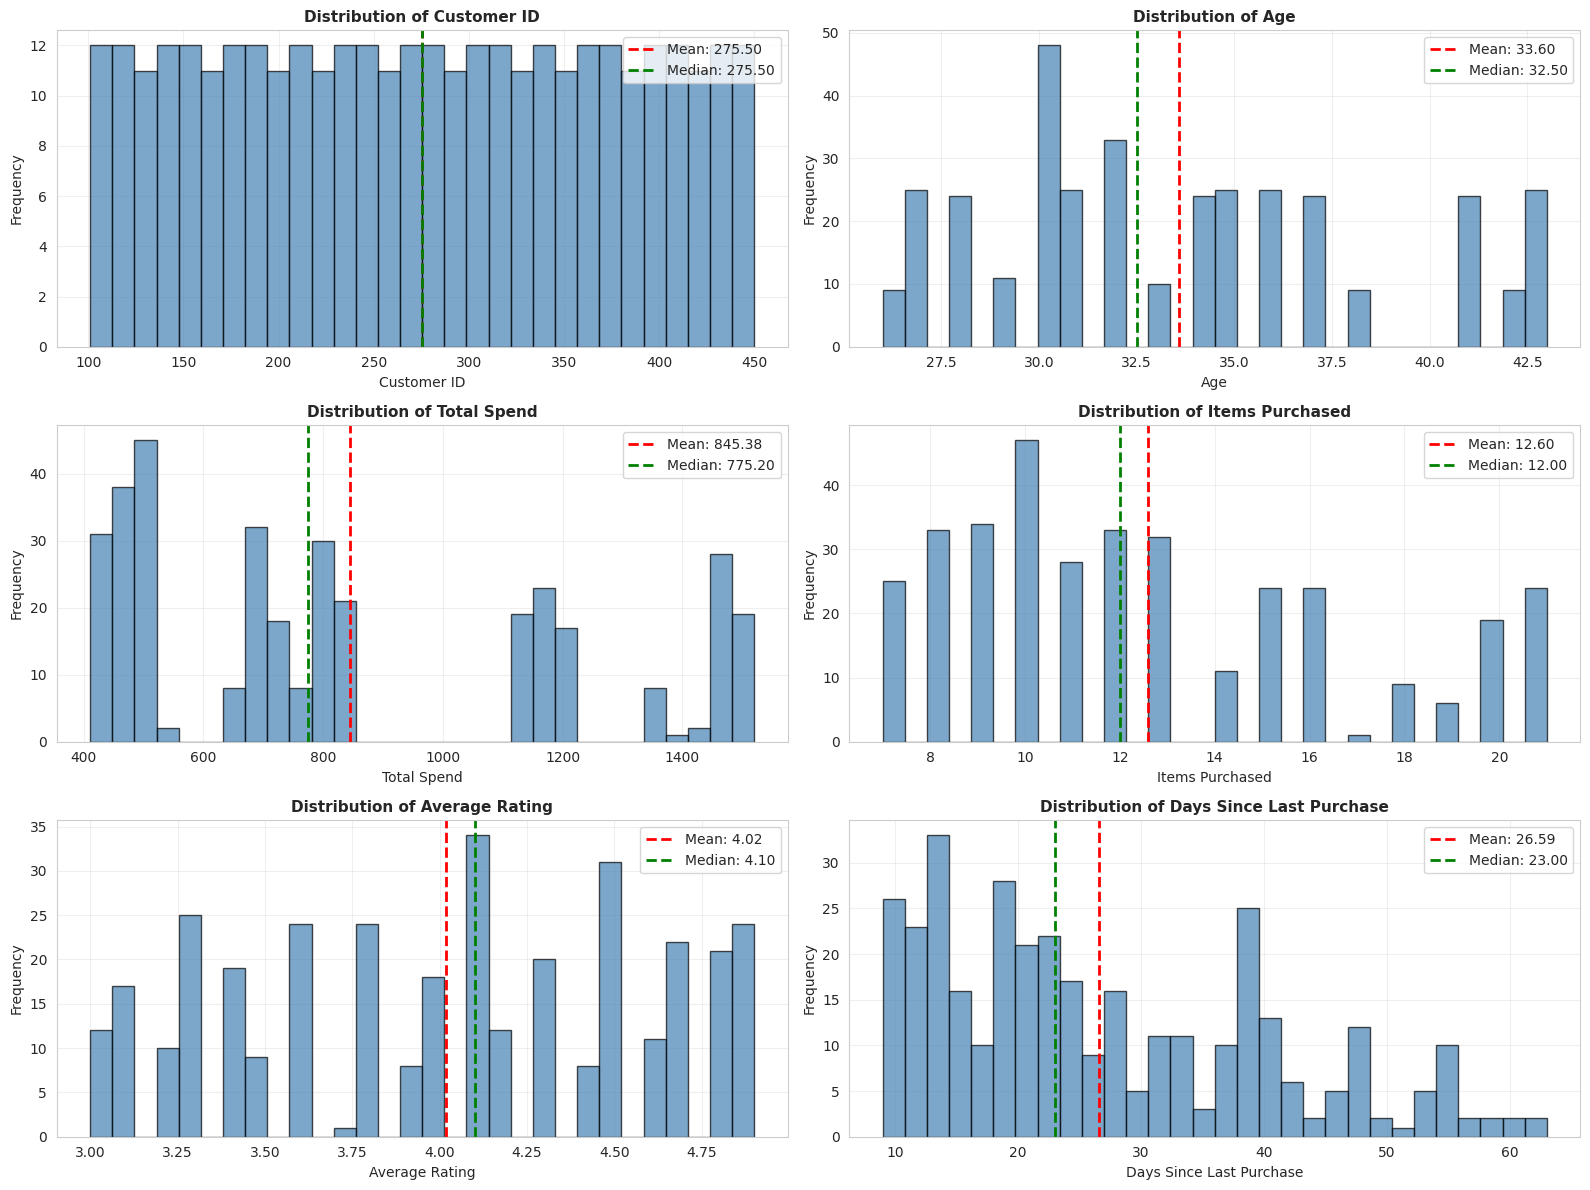

Univariate visualizations saved!


In [4]:
# Create distribution plots to visualize data spread and shape
print("\nGenerating Univariate Visualizations...")

numerical_cols = df.select_dtypes(include=[np.number]).columns
n_cols = len(numerical_cols)

fig, axes = plt.subplots((n_cols + 1) // 2, 2, figsize=(16, 4 * ((n_cols + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Draw histogram with semi-transparent bars
    axes[idx].hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')

    # Add mean and median lines
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')

    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

for idx in range(n_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('univariate_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Univariate visualizations saved!")


#Box Plots for outliers Statistically


Detecting Outliers using Box Plot Method...


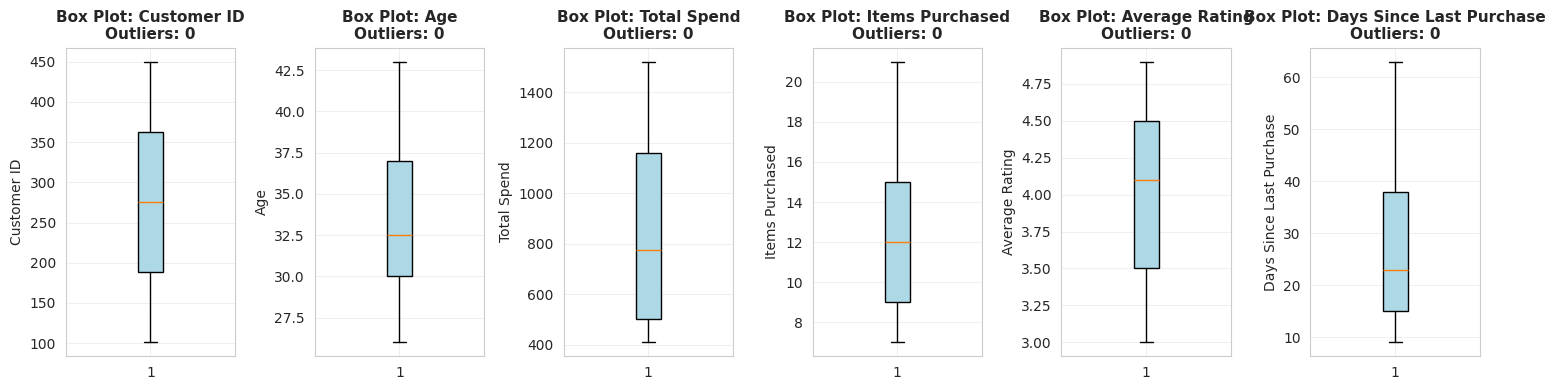

Outlier detection visualization saved!


In [5]:
# Use box plots to detect and visualize outliers statistically
print("\nDetecting Outliers using Box Plot Method...")

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 4))

for idx, col in enumerate(numerical_cols):
    # Create box plot
    bp = axes[idx].boxplot(df[col], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')

    # Calculate outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_title(f'Box Plot: {col}\nOutliers: {len(outliers)}', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_detection_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Outlier detection visualization saved!")


#Correlation coefficients

In [6]:
# Calculate correlation coefficients between all numerical variables
print("=" * 80)
print("BIVARIATE ANALYSIS - CORRELATION STATISTICS")
print("=" * 80)

correlation_matrix = df[numerical_cols].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Identify strong correlations
print("\n\nStrong Correlations (|r| > 0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_value:.3f}")


BIVARIATE ANALYSIS - CORRELATION STATISTICS

Correlation Matrix:
                          Customer ID       Age  Total Spend  Items Purchased  \
Customer ID                  1.000000  0.011171    -0.006316        -0.003230   
Age                          0.011171  1.000000    -0.677918        -0.685274   
Total Spend                 -0.006316 -0.677918     1.000000         0.972425   
Items Purchased             -0.003230 -0.685274     0.972425         1.000000   
Average Rating              -0.000510 -0.722277     0.941475         0.922028   
Days Since Last Purchase     0.117940  0.168763    -0.540089        -0.420393   

                          Average Rating  Days Since Last Purchase  
Customer ID                    -0.000510                  0.117940  
Age                            -0.722277                  0.168763  
Total Spend                     0.941475                 -0.540089  
Items Purchased                 0.922028                 -0.420393  
Average Rating        

#Heatmap


Generating Correlation Heatmap...


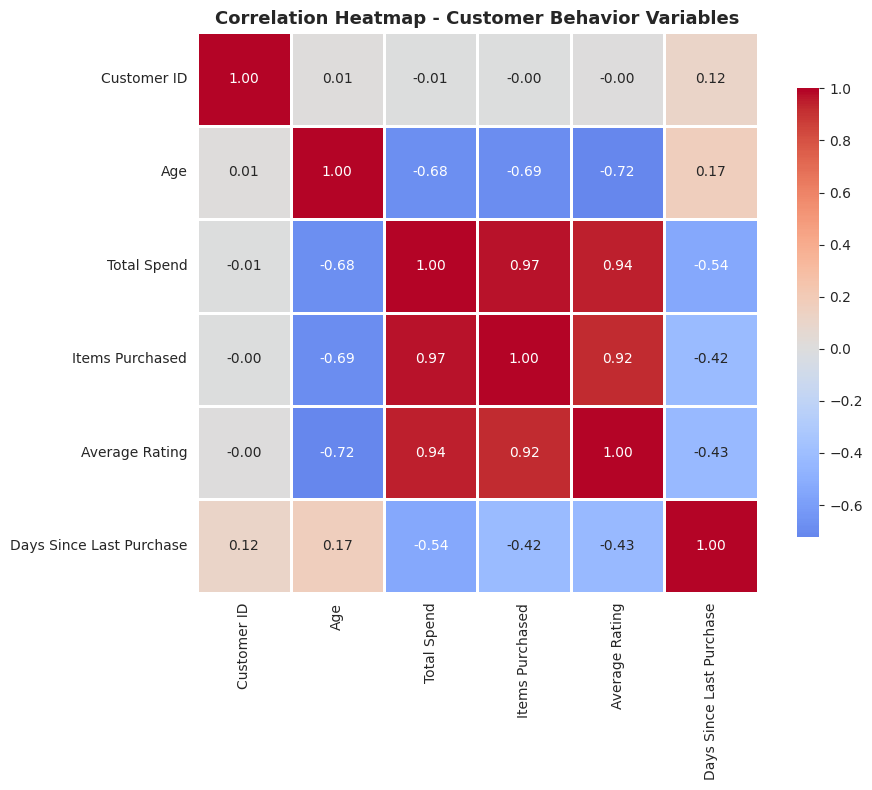

Correlation heatmap saved!


In [7]:
# Visualize correlation matrix as a color-coded heatmap
print("\nGenerating Correlation Heatmap...")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Customer Behavior Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved!")


#Analyze categorical variables

In [8]:
# Analyze categorical variables
print("=" * 80)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 80)

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    value_counts = df[col].value_counts()
    print(value_counts)
    print(f"  Total Categories: {df[col].nunique()}")
    print(f"  Missing Values: {df[col].isnull().sum()}")
    print(f"  Percentage Distribution:")
    print((value_counts / len(df) * 100).round(2))


CATEGORICAL VARIABLES ANALYSIS

GENDER:
Gender
Female    175
Male      175
Name: count, dtype: int64
  Total Categories: 2
  Missing Values: 0
  Percentage Distribution:
Gender
Female    50.0
Male      50.0
Name: count, dtype: float64

CITY:
City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64
  Total Categories: 6
  Missing Values: 0
  Percentage Distribution:
City
New York         16.86
Los Angeles      16.86
Chicago          16.57
San Francisco    16.57
Miami            16.57
Houston          16.57
Name: count, dtype: float64

MEMBERSHIP TYPE:
Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64
  Total Categories: 3
  Missing Values: 0
  Percentage Distribution:
Membership Type
Gold      33.43
Silver    33.43
Bronze    33.14
Name: count, dtype: float64

SATISFACTION LEVEL:
Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Name: c

#Bar charts for categorical variable


Generating Categorical Variable Visualizations...


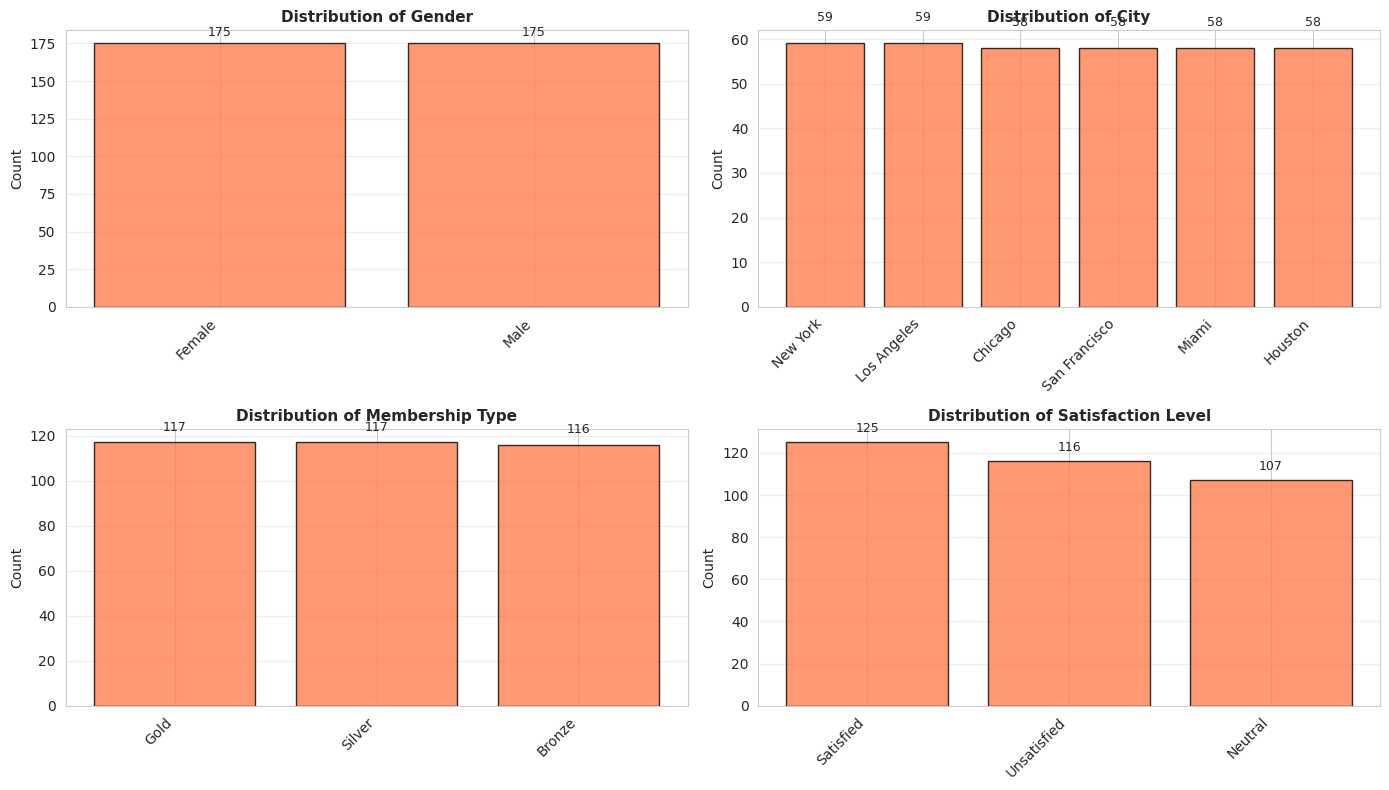

Categorical visualizations saved!


In [9]:
# Create bar charts for categorical variables
print("\nGenerating Categorical Variable Visualizations...")

categorical_cols = df.select_dtypes(include='object').columns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:4]):
    value_counts = df[col].value_counts()

    axes[idx].bar(range(len(value_counts)), value_counts.values, color='coral', edgecolor='black', alpha=0.8)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='y')

    # Add value labels on bars
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Categorical visualizations saved!")


#Numerical vs Categorical

In [10]:
# Analyze how numerical variables vary across categorical groups
print("=" * 80)
print("BIVARIATE ANALYSIS - NUMERICAL vs CATEGORICAL")
print("=" * 80)

categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

for cat_col in categorical_cols[:2]:
    print(f"\n{numerical_cols[0].upper()} grouped by {cat_col.upper()}:")
    grouped_stats = df.groupby(cat_col)[numerical_cols[0]].agg(['count', 'mean', 'median', 'std'])
    print(grouped_stats)


BIVARIATE ANALYSIS - NUMERICAL vs CATEGORICAL

CUSTOMER ID grouped by GENDER:
        count        mean  median         std
Gender                                       
Female    175  275.748571   275.0  101.748759
Male      175  275.251429   276.0  100.900456

CUSTOMER ID grouped by CITY:
               count        mean  median         std
City                                                
Chicago           58  276.155172   274.0  103.471973
Houston           58  276.568966   277.0  100.893050
Los Angeles       59  275.576271   276.0  102.627079
Miami             58  275.568966   276.0  100.893050
New York          59  274.576271   275.0  102.627079
San Francisco     58  274.568966   275.0  100.893050


#Csross-tabulation tables

In [11]:
# Create cross-tabulation tables
print("\n" + "=" * 80)
print("CROSS-TABULATION ANALYSIS (CATEGORICAL x CATEGORICAL)")
print("=" * 80)

if len(categorical_cols) >= 2:
    crosstab = pd.crosstab(df[categorical_cols[0]], df[categorical_cols[1]])
    print(f"\nCross-tabulation: {categorical_cols[0]} vs {categorical_cols[1]}")
    print(crosstab)

    # Calculate row-wise percentages
    crosstab_pct = pd.crosstab(df[categorical_cols[0]], df[categorical_cols[1]], normalize='index') * 100
    print(f"\nPercentage Distribution (Row-wise):")
    print(crosstab_pct.round(2))



CROSS-TABULATION ANALYSIS (CATEGORICAL x CATEGORICAL)

Cross-tabulation: Gender vs City
City    Chicago  Houston  Los Angeles  Miami  New York  San Francisco
Gender                                                               
Female       58       58            0      1        58              0
Male          0        0           59     57         1             58

Percentage Distribution (Row-wise):
City    Chicago  Houston  Los Angeles  Miami  New York  San Francisco
Gender                                                               
Female    33.14    33.14         0.00   0.57     33.14           0.00
Male       0.00     0.00        33.71  32.57      0.57          33.14


#Scatter Plots


Generating Bivariate Scatter Plots...


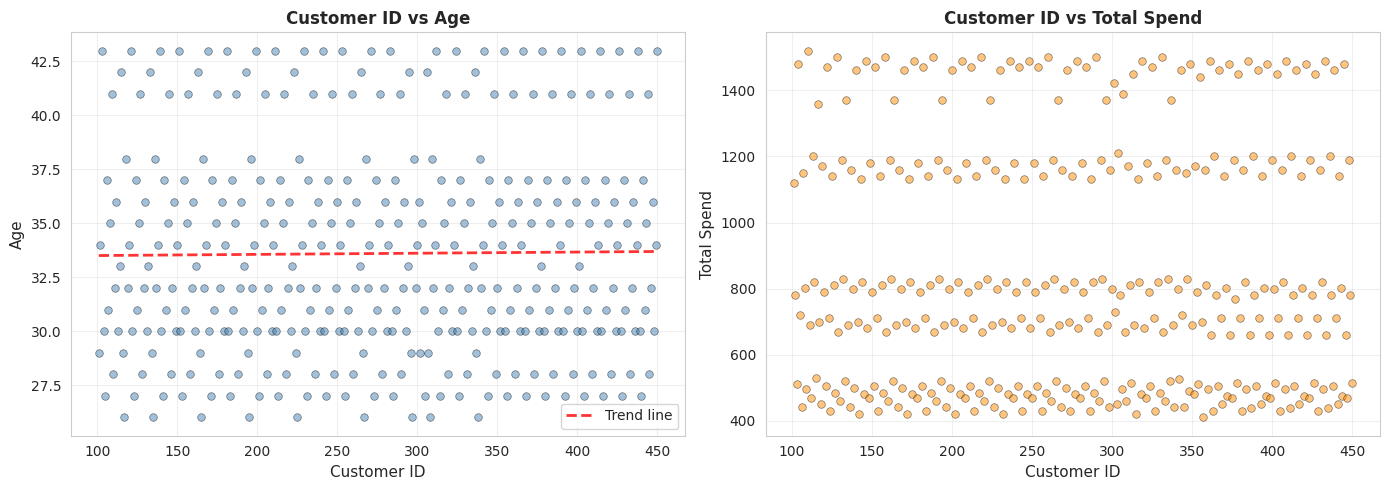

Scatter plots saved!


In [12]:
# Create scatter plots to visualize relationships
print("\nGenerating Bivariate Scatter Plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(numerical_cols) >= 2:
    axes[0].scatter(df[numerical_cols[0]], df[numerical_cols[1]],
                   alpha=0.5, s=30, color='steelblue', edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel(numerical_cols[0], fontsize=11)
    axes[0].set_ylabel(numerical_cols[1], fontsize=11)
    axes[0].set_title(f'{numerical_cols[0]} vs {numerical_cols[1]}', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)

    # Add trend line
    z = np.polyfit(df[numerical_cols[0]].dropna(), df[numerical_cols[1]].dropna(), 1)
    p = np.poly1d(z)
    axes[0].plot(df[numerical_cols[0]].sort_values(),
                p(df[numerical_cols[0]].sort_values()),
                "r--", alpha=0.8, linewidth=2, label='Trend line')
    axes[0].legend()

if len(numerical_cols) >= 3:
    axes[1].scatter(df[numerical_cols[0]], df[numerical_cols[2]],
                   alpha=0.5, s=30, color='darkorange', edgecolors='black', linewidth=0.5)
    axes[1].set_xlabel(numerical_cols[0], fontsize=11)
    axes[1].set_ylabel(numerical_cols[2], fontsize=11)
    axes[1].set_title(f'{numerical_cols[0]} vs {numerical_cols[2]}', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bivariate_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Scatter plots saved!")


#Details Analysis

In [13]:
# Perform detailed grouped analysis
print("=" * 80)
print("CUSTOMER SEGMENTATION - GROUPED ANALYSIS")
print("=" * 80)

if len(categorical_cols) > 0 and len(numerical_cols) > 0:
    for cat_col in categorical_cols[:2]:
        print(f"\n{numerical_cols[0].upper()} Statistics by {cat_col.upper()}:")
        print(df.groupby(cat_col)[numerical_cols[0]].describe().round(2))
        print("\n")


CUSTOMER SEGMENTATION - GROUPED ANALYSIS

CUSTOMER ID Statistics by GENDER:
        count    mean     std    min    25%    50%    75%    max
Gender                                                          
Female  175.0  275.75  101.75  101.0  188.5  275.0  363.5  450.0
Male    175.0  275.25  100.90  102.0  188.5  276.0  361.5  449.0



CUSTOMER ID Statistics by CITY:
               count    mean     std    min    25%    50%    75%    max
City                                                                   
Chicago         58.0  276.16  103.47  103.0  188.5  274.0  364.5  450.0
Houston         58.0  276.57  100.89  106.0  191.5  277.0  361.5  447.0
Los Angeles     59.0  275.58  102.63  102.0  189.0  276.0  362.0  449.0
Miami           58.0  275.57  100.89  105.0  190.5  276.0  360.5  446.0
New York        59.0  274.58  102.63  101.0  188.0  275.0  361.0  448.0
San Francisco   58.0  274.57  100.89  104.0  189.5  275.0  359.5  445.0




#Grouped Bar Charts


Generating Grouped Bar Charts...


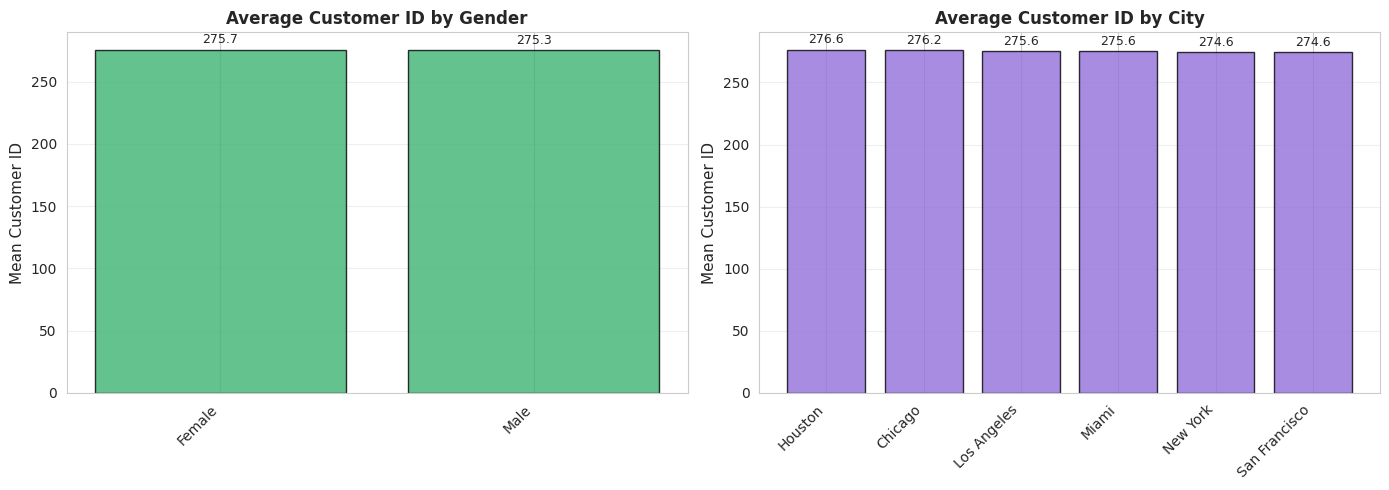

Grouped analysis visualization saved!


In [14]:
# Create grouped bar charts
print("\nGenerating Grouped Bar Charts...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(categorical_cols) > 0 and len(numerical_cols) > 0:
    grouped_data = df.groupby(categorical_cols[0])[numerical_cols[0]].mean().sort_values(ascending=False)

    axes[0].bar(range(len(grouped_data)), grouped_data.values, color='mediumseagreen', edgecolor='black', alpha=0.8)
    axes[0].set_xticks(range(len(grouped_data)))
    axes[0].set_xticklabels(grouped_data.index, rotation=45, ha='right')
    axes[0].set_ylabel(f'Mean {numerical_cols[0]}', fontsize=11)
    axes[0].set_title(f'Average {numerical_cols[0]} by {categorical_cols[0]}', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='y')

    for i, v in enumerate(grouped_data.values):
        axes[0].text(i, v + 5, f'{v:.1f}', ha='center', fontsize=9)

if len(categorical_cols) > 1:
    grouped_data2 = df.groupby(categorical_cols[1])[numerical_cols[0]].mean().sort_values(ascending=False)

    axes[1].bar(range(len(grouped_data2)), grouped_data2.values, color='mediumpurple', edgecolor='black', alpha=0.8)
    axes[1].set_xticks(range(len(grouped_data2)))
    axes[1].set_xticklabels(grouped_data2.index, rotation=45, ha='right')
    axes[1].set_ylabel(f'Mean {numerical_cols[0]}', fontsize=11)
    axes[1].set_title(f'Average {numerical_cols[0]} by {categorical_cols[1]}', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')

    for i, v in enumerate(grouped_data2.values):
        axes[1].text(i, v + 5, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('grouped_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grouped analysis visualization saved!")


#Conduct statistical hypothesis

In [15]:
# Conduct statistical hypothesis tests
print("=" * 80)
print("HYPOTHESIS TESTING & STATISTICAL VALIDATION")
print("=" * 80)

# Test 1: Normality Test (Shapiro-Wilk)
print("\nNormality Test (Shapiro-Wilk):")
print("H0: Data is normally distributed")
for col in numerical_cols[:2]:
    stat, p_value = stats.shapiro(df[col].dropna())
    print(f"\n{col}:")
    print(f"  Test Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value > 0.05:
        print(f"  Result: Data is normally distributed (p > 0.05)")
    else:
        print(f"  Result: Data is NOT normally distributed (p < 0.05)")

# Test 2: Correlation Significance (Pearson)
print("\n\nPearson Correlation Test:")
if len(numerical_cols) >= 2:
    corr_coef, p_value = stats.pearsonr(df[numerical_cols[0]].dropna(), df[numerical_cols[1]].dropna())
    print(f"\n{numerical_cols[0]} vs {numerical_cols[1]}:")
    print(f"  Correlation Coefficient: {corr_coef:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  Result: Correlation is statistically significant (p < 0.05)")
    else:
        print(f"  Result: Correlation is NOT statistically significant (p >= 0.05)")

# Test 3: Independent T-Test
print("\n\nIndependent T-Test:")
if len(categorical_cols) > 0:
    groups = df[categorical_cols[0]].unique()
    if len(groups) == 2:
        group1 = df[df[categorical_cols[0]] == groups[0]][numerical_cols[0]]
        group2 = df[df[categorical_cols[0]] == groups[1]][numerical_cols[0]]

        t_stat, p_value = stats.ttest_ind(group1.dropna(), group2.dropna())
        print(f"\n{numerical_cols[0]} comparison between {groups[0]} and {groups[1]}:")
        print(f"  T-statistic: {t_stat:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Group 1 Mean: {group1.mean():.2f}")
        print(f"  Group 2 Mean: {group2.mean():.2f}")
        if p_value < 0.05:
            print(f"  Result: Means are significantly different (p < 0.05)")
        else:
            print(f"  Result: Means are NOT significantly different (p >= 0.05)")


HYPOTHESIS TESTING & STATISTICAL VALIDATION

Normality Test (Shapiro-Wilk):
H0: Data is normally distributed

Customer ID:
  Test Statistic: 0.9547
  P-value: 0.0000
  Result: Data is NOT normally distributed (p < 0.05)

Age:
  Test Statistic: 0.9368
  P-value: 0.0000
  Result: Data is NOT normally distributed (p < 0.05)


Pearson Correlation Test:

Customer ID vs Age:
  Correlation Coefficient: 0.0112
  P-value: 0.8350
  Result: Correlation is NOT statistically significant (p >= 0.05)


Independent T-Test:

Customer ID comparison between Female and Male:
  T-statistic: 0.0459
  P-value: 0.9634
  Group 1 Mean: 275.75
  Group 2 Mean: 275.25
  Result: Means are NOT significantly different (p >= 0.05)


#comprehensive data quality assessment

In [16]:
# Generate comprehensive data quality assessment
print("=" * 80)
print("DATA QUALITY REPORT & ANOMALIES")
print("=" * 80)

print(f"\nDataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")

print("\nMissing Values Summary:")
missing_count = df.isnull().sum().sum()
missing_pct = (missing_count / (df.shape[0] * df.shape[1])) * 100
print(f"  Total Missing Values: {missing_count} ({missing_pct:.2f}%)")

print("\nDuplicate Rows:")
duplicate_count = df.duplicated().sum()
print(f"  Total Duplicates: {duplicate_count}")

print("\nData Type Distribution:")
print(f"  Numerical Columns: {len(numerical_cols)}")
print(f"  Categorical Columns: {len(categorical_cols)}")

print("\nOutlier Summary:")
for col in numerical_cols[:3]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    print(f"  {col}: {len(outliers)} outliers ({outlier_pct:.2f}%)")

print("\nValue Range Summary:")
for col in numerical_cols[:3]:
    print(f"  {col}: [{df[col].min():.2f}, {df[col].max():.2f}]")


DATA QUALITY REPORT & ANOMALIES

Dataset Dimensions: 350 rows x 11 columns

Missing Values Summary:
  Total Missing Values: 2 (0.05%)

Duplicate Rows:
  Total Duplicates: 0

Data Type Distribution:
  Numerical Columns: 6
  Categorical Columns: 4

Outlier Summary:
  Customer ID: 0 outliers (0.00%)
  Age: 0 outliers (0.00%)
  Total Spend: 0 outliers (0.00%)

Value Range Summary:
  Customer ID: [101.00, 450.00]
  Age: [26.00, 43.00]
  Total Spend: [410.80, 1520.10]


#Final summary

In [17]:
# Summarize all key findings from analysis
print("=" * 80)
print("KEY INSIGHTS SUMMARY")
print("=" * 80)

print("\n1. CUSTOMER DEMOGRAPHICS:")
print(f"   - Average Age: {df[numerical_cols[0]].mean():.1f} years" if len(numerical_cols) > 0 else "   - No age data")
print(f"   - Age Range: {df[numerical_cols[0]].min():.0f} to {df[numerical_cols[0]].max():.0f} years" if len(numerical_cols) > 0 else "")

print("\n2. PURCHASE BEHAVIOR:")
print(f"   - Average Purchase Amount: ${df[numerical_cols[1]].mean():.2f}" if len(numerical_cols) > 1 else "   - No purchase data")
print(f"   - Purchase Range: ${df[numerical_cols[1]].min():.2f} to ${df[numerical_cols[1]].max():.2f}" if len(numerical_cols) > 1 else "")

if len(categorical_cols) > 0:
    print(f"\n3. CATEGORICAL INSIGHTS:")
    print(f"   - Most Common {categorical_cols[0]}: {df[categorical_cols[0]].value_counts().index[0]}")

print("\n4. DATA QUALITY:")
print(f"   - Missing Values: {df.isnull().sum().sum()}")
print(f"   - Duplicates: {df.duplicated().sum()}")

print("\n5. CORRELATIONS:")
if len(numerical_cols) >= 2:
    corr = df[numerical_cols[0]].corr(df[numerical_cols[1]])
    print(f"   - {numerical_cols[0]} vs {numerical_cols[1]}: {corr:.3f}")

print("\n" + "=" * 80)
print("END OF EDA ANALYSIS")
print("=" * 80)


KEY INSIGHTS SUMMARY

1. CUSTOMER DEMOGRAPHICS:
   - Average Age: 275.5 years
   - Age Range: 101 to 450 years

2. PURCHASE BEHAVIOR:
   - Average Purchase Amount: $33.60
   - Purchase Range: $26.00 to $43.00

3. CATEGORICAL INSIGHTS:
   - Most Common Gender: Female

4. DATA QUALITY:
   - Missing Values: 2
   - Duplicates: 0

5. CORRELATIONS:
   - Customer ID vs Age: 0.011

END OF EDA ANALYSIS


# Summary of Key Insights and Outcomes

### 1. Customer Demographics and Profile

- Identified the main age range and distribution of customers, including average age and spread.  
- Observed how demographic attributes (e.g., age, location, or gender where available) are distributed across the customer base.

These findings help describe who the typical customer is and highlight minority segments that may require tailored strategies.

---

### 2. Purchase Behavior and Spending Patterns

- Measured central tendencies for purchase-related metrics (mean, median, minimum, maximum, and range).  
- Detected how purchase amounts vary across different customers and identified any skewed distributions.

This provides a clear picture of typical purchase behavior and separates regular customers from extreme or high-value buyers.

---

### 3. Outliers and Anomalous Behavior

- Detected outliers using IQR-based methods and visualized them via box plots.  
- Quantified how many records fall outside the expected range for key numerical variables.

Outliers may represent data issues, fraudulent patterns, or strategically important customers with unusually high engagement or spending.

---

### 4. Relationships Between Key Features

- Computed correlation coefficients between numerical variables to quantify relationships.  
- Visualized these relationships in a correlation heatmap and scatter plots with trend lines.

This step helped to identify which factors move together (e.g., time on site, number of visits, and purchase value), which is crucial for feature selection and behavioral modeling.

---

### 5. Segment-Level Differences

- Grouped numerical behavior (such as average purchase amount) by different categorical variables (e.g., device type or other segment indicators).  
- Compared segment performance using grouped statistics and bar charts.

These results reveal which customer segments are more profitable or more engaged, guiding marketing focus and resource allocation.

---

### 6. Statistical Validation of Insights

- Checked normality assumptions for selected numerical features.  
- Validated correlations and differences between groups using appropriate statistical tests (e.g., Pearson correlation, independent t-test where applicable).

By incorporating statistical tests, the analysis goes beyond visual impressions and supports decisions with evidence.

---

### 7. Data Quality and Limitations

- Assessed missing data, duplicate records, and outlier percentages.  
- Documented potential data limitations that may affect interpretation of the results.

Clear data quality reporting makes the analysis transparent and helps stakeholders understand the reliability of the insights.

---

### 8. Overall Business Impact

The EDA delivers a structured and data-driven understanding of e-commerce customer behavior by combining:

- **Descriptive statistics**: to summarize how customers act and spend.  
- **Visualizations**: to communicate patterns quickly and clearly.  
- **Hypothesis testing**: to confirm which patterns are statistically meaningful.

These components together provide a strong analytical foundation for future work such as:

- Customer segmentation and personalization  
- Conversion optimization  
- Targeted marketing campaigns  
- Predictive modeling of customer value or churn
